[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/semantica-agi/semantica/blob/main/cookbook/introduction/08_Your_First_Knowledge_Graph.ipynb)

# 🚀 Your First Knowledge Graph

## Overview

This notebook walks you through creating your first knowledge graph from a simple document. You'll learn the complete end-to-end workflow from ingesting a file to visualizing the resulting knowledge graph — and every step consumes the real output of the step before it.

> [!TIP]
> This is the perfect starting point if you are new to Semantica. No prior knowledge of knowledge graphs is required!

**Documentation**: [API Reference](https://semantica.readthedocs.io/reference/kg/)

### 🎯 Learning Objectives

- **Understand the Workflow**: Learn the `File → Parse → Extract → Graph → Visualize` pipeline
- **Ingest Data**: Load documents using `FileIngestor`
- **Parse Content**: Extract text using `DocumentParser`
- **Extract Knowledge**: Identify entities and relations using `NERExtractor` and `RelationExtractor`
- **Build Graph**: Construct a graph using `GraphBuilder`
- **Visualize**: See your graph come to life with `KGVisualizer`

## Installation

Install Semantica from PyPI:

```bash
pip install semantica
# Or with all optional dependencies:
pip install semantica[all]
```

---

## 🔄 Simple End-to-End Workflow

The complete workflow consists of five main steps:

1. **📥 Ingest** - Load data from files or other sources
2. **📄 Parse** - Extract and structure content from documents
3. **⛏️ Extract** - Identify entities and relationships
4. **🕸️ Build Graph** - Construct the knowledge graph
5. **📊 Visualize** - Render and analyze the graph

Each step is demonstrated in the code cells below, and each cell can be rerun on its own: the sample file is only removed by the optional cleanup cell at the very end.

> [!TIP]
> **Alternative: Using Semantica Framework**
>
> For a simpler, high-level approach, you can use the `Semantica` framework class which orchestrates all these steps:
>
> ```python
> from semantica.core import Semantica
>
> framework = Semantica()
> framework.initialize()
>
> result = framework.build_knowledge_base(
>     sources=["sample_document.txt"],
>     embeddings=True,
>     graph=True
> )
>
> framework.shutdown()
> ```
>
> This notebook shows the step-by-step approach for learning. See [Core Module Usage Guide](../../../semantica/core/core_usage.md) for more details.

---

## 📂 Step 1: Ingest a File

In this step, we'll use `FileIngestor` to load a document. The ingestor supports various file formats including PDF, DOCX, TXT, and more. Writing the sample file is idempotent, so this cell can be rerun at any time.


In [1]:
%pip install semantica

# spaCy models are distributed separately from the spaCy library. This lesson
# relies on the English model to recognize standalone places such as Cupertino.
import sys
import subprocess
import spacy

try:
    spacy.load("en_core_web_sm")
except OSError:
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])


Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 5.8 MB/s  0:00:02 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
from pathlib import Path

from semantica.ingest import FileIngestor

sample_text = """Apple Inc. is headquartered in Cupertino, California.
In 1976, Steve Jobs founded Apple Inc.
Tim Cook is the CEO of Apple Inc.
"""

sample_file = Path("sample_document.txt")
sample_file.write_text(sample_text)

print(f"File: {sample_file}")
print(f"Content length: {len(sample_text)} characters")

ingestor = FileIngestor()
file_object = ingestor.ingest_file(sample_file, read_content=True)
print(f"  File name: {file_object.name}")
print(f"  File type: {file_object.file_type}")
print(f"  Content available: {file_object.content is not None}")

File: sample_document.txt
Content length: 127 characters


Status,Action,Module,Submodule,Progress,ETA,Rate,Time,Extracted
✅,Semantica is ingesting,📥 ingest,FileIngestor,100.0%,-,-,0.00s,-
✅,Semantica is parsing,🔍 parse,DocumentParser,100.0%,-,-,0.00s,-
✅,Semantica is extracting,🎯 semantic_extract,NERExtractor,100.0%,-,-,0.02s,-
✅,Semantica is extracting,🎯 semantic_extract,RelationExtractor,100.0%,-,-,0.01s,-
✅,Semantica is building,🧠 kg,GraphBuilder,100.0% (3/3),-,0.1/s,0.00s,-
✅,Semantica is resolving,⚠️ conflicts,ConflictDetector,100.0% (0/8),-,-,0.01s,-
✅,Semantica is visualizing,📈 visualization,KGVisualizer,100.0%,-,-,0.08s,-


🔄 Semantica is ingesting: File: sample_document.txt 📥 ingest FileIngestor |░░░░░░░░░░░░░░░| 0.0% ETA: - Rate: - Time: 0.00s Extracted: -

  File name: sample_document.txt
  File type: txt
  Content available: True


## 📄 Step 2: Parse the Document

After ingesting the file, we need to parse it to extract the text content. `DocumentParser.parse_document()` returns the extracted text under the `"text"` key.


In [4]:
from semantica.parse import DocumentParser

parser = DocumentParser()
parsed_document = parser.parse_document(str(sample_file))

parsed_content = parsed_document.get("text", "")
assert parsed_content.strip(), "Parsing produced no text — check the input file"

print(f"Parsed content length: {len(parsed_content)} characters")
print(f"Preview: {parsed_content[:120]}...")

🔄 Semantica is parsing: Document: sample_document.txt 🔍 parse DocumentParser |░░░░░░░░░░░░░░░| 0.0% ETA: - Rate: - Time: 0.00s Extracted: -

Parsed content length: 127 characters
Preview: Apple Inc. is headquartered in Cupertino, California.
In 1976, Steve Jobs founded Apple Inc.
Tim Cook is the CEO of Appl...


## ⛏️ Step 3: Extract Entities and Relations

Now we'll extract entities and relations from the parsed text. `NERExtractor` identifies people, organizations, locations and dates; `RelationExtractor` finds relations between those mentions. Both operate on the *parsed content from Step 2* — not on a copy of the raw string.


In [5]:
from semantica.semantic_extract import NERExtractor, RelationExtractor

ner_extractor = NERExtractor()
relation_extractor = RelationExtractor()

mentions = ner_extractor.extract(parsed_content)
relations = relation_extractor.extract(parsed_content, mentions)

print("Entity mentions:")
for mention in mentions:
    print(f"  {mention.text!r:<13} {mention.label:<7} span=[{mention.start_char}:{mention.end_char}]")

print("\nExtracted relations:")
for rel in relations:
    print(f"  {rel.subject.text!r} --{rel.predicate}--> {rel.object.text!r}")

🔄 Semantica is extracting: Extracting named entities from text 🎯 semantic_extract NERExtractor |░░░░░░░░░░░░░░░| 0.0% ETA: - Rate: - Time: 0.00s Extracted: -

Entity mentions:
  'Apple Inc.'  ORG     span=[0:10]
  'Cupertino'   GPE     span=[31:40]
  'California'  GPE     span=[42:52]
  '1976'        DATE    span=[57:61]
  'Steve Jobs'  PERSON  span=[63:73]
  'Apple Inc.'  ORG     span=[82:92]
  'Tim Cook'    PERSON  span=[93:101]
  'Apple Inc.'  ORG     span=[116:126]

Extracted relations:
  'Apple Inc.' --founded_by--> 'Steve Jobs'
  'Apple Inc.' --located_in--> 'Cupertino'
  'Tim Cook' --works_for--> 'Apple Inc.'


## 🕸️ Step 4: Build the Knowledge Graph

Using the extracted entities and relations, we construct a knowledge graph with `GraphBuilder`. Every mention gets a graph ID, and each edge is built from the actual `Relation.subject` / `Relation.object` endpoints.

> [!NOTE]
> The graph will contain one node per *mention*, so `Apple Inc.` appears three times. Merging duplicate mentions into one canonical entity is covered in [07_Building_Knowledge_Graphs.ipynb](./07_Building_Knowledge_Graphs.ipynb).


In [6]:
from semantica.kg import GraphBuilder

entities = []
span_to_id = {}
for i, mention in enumerate(mentions, 1):
    graph_id = f"e{i}"
    span_to_id[(mention.start_char, mention.end_char)] = graph_id
    entities.append({
        "id": graph_id,
        "type": mention.label,
        "name": mention.text,
        "properties": {},
    })

relationships = []
for rel in relations:
    source_id = span_to_id.get((rel.subject.start_char, rel.subject.end_char))
    target_id = span_to_id.get((rel.object.start_char, rel.object.end_char))
    if source_id is None or target_id is None:
        print(f"Skipping relation with unmapped endpoint: "
              f"{rel.subject.text!r} --{rel.predicate}--> {rel.object.text!r}")
        continue
    relationships.append({
        "source": source_id,
        "target": target_id,
        "type": rel.predicate,
        "properties": {},
    })

builder = GraphBuilder()
knowledge_graph = builder.build({"entities": entities, "relationships": relationships})

id_to_name = {entity["id"]: entity["name"] for entity in entities}

print(f"Nodes (entities): {len(knowledge_graph['entities'])}")
for entity in knowledge_graph["entities"]:
    print(f"  {entity['id']}: {entity['name']} ({entity['type']})")

print(f"\nEdges (relationships): {len(knowledge_graph['relationships'])}")
for relationship in knowledge_graph["relationships"]:
    print(f"  {id_to_name[relationship['source']]} "
          f"--{relationship['type']}--> {id_to_name[relationship['target']]}")

edges = {
    (id_to_name[r["source"]], r["type"], id_to_name[r["target"]])
    for r in knowledge_graph["relationships"]
}
assert ("Apple Inc.", "located_in", "Cupertino") in edges
assert ("Tim Cook", "works_for", "Apple Inc.") in edges

🔄 Semantica is building: Knowledge graph from 1 source(s) 🧠 kg GraphBuilder |░░░░░░░░░░░░░░░| 0.0% ETA: - Rate: - Time: 0.00s Extracted: -🔄 Semantica is building: Processing entities... 8/8 🧠 kg GraphBuilder |███████████████| 100.0% ETA: - Rate: 10346.7/s Time: 0.00s Extracted: -🔄 Semantica is building: Processing relationships... 3/3 🧠 kg GraphBuilder |███████████████| 100.0% ETA: - Rate: 3285.4/s Time: 0.00s Extracted: -🔄 Semantica is resolving: Checking fields for conflicts... 0/2 (remaining: 2) ⚠️ conflicts ConflictDetector |░░░░░░░░░░░░░░░| 0.0% ETA: - Rate: - Time: 0.00s Extracted: -🔄 Semantica is resolving: Analyzing entities... 0/8 (remaining: 8) ⚠️ conflicts ConflictDetector |░░░░░░░░░░░░░░░| 0.0% ETA: - Rate: - Time: 0.00s Extracted: -🔄 Semantica is resolving: Analyzing entities... 1/8 (remaining: 7) ⚠️ conflicts ConflictDetector |█░░░░░░░░░░░░░░| 12.5% ETA: 0.0s Rate: 488.5/s Time: 0.00s Extracted: -🔄 Semantica is resolving: Analyzing entities... 2/8 (remaining: 6) ⚠️ confli

Nodes (entities): 8
  e1: Apple Inc. (ORG)
  e2: Cupertino (GPE)
  e3: California (GPE)
  e4: 1976 (DATE)
  e5: Steve Jobs (PERSON)
  e6: Apple Inc. (ORG)
  e7: Tim Cook (PERSON)
  e8: Apple Inc. (ORG)

Edges (relationships): 3
  Apple Inc. --founded_by--> Steve Jobs
  Apple Inc. --located_in--> Cupertino
  Tim Cook --works_for--> Apple Inc.


## 📊 Step 5: Visualize and Analyze

Finally, we render the knowledge graph with `KGVisualizer` and look at its structure. `visualize_network()` accepts the `GraphBuilder` result directly and can save an interactive HTML file.


🔄 Semantica is visualizing: Visualizing knowledge graph network 📈 visualization KGVisualizer |░░░░░░░░░░░░░░░| 0.0% ETA: - Rate: - Time: 0.00s Extracted: -

Saved interactive visualization to knowledge_graph.html

Entities by type:
  - DATE: 1
  - GPE: 2
  - ORG: 3
  - PERSON: 2

Relationships by type:
  - founded_by: 1
  - located_in: 1
  - works_for: 1


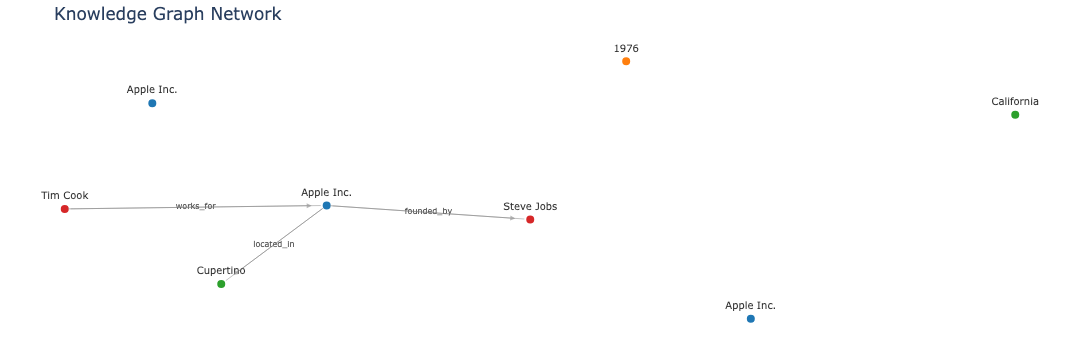

In [7]:
from semantica.visualization import KGVisualizer

visualizer = KGVisualizer()
fig = visualizer.visualize_network(
    knowledge_graph, output="html", file_path="knowledge_graph.html"
)
print("Saved interactive visualization to knowledge_graph.html")

entity_types = {}
for entity in knowledge_graph["entities"]:
    entity_types[entity["type"]] = entity_types.get(entity["type"], 0) + 1

print("\nEntities by type:")
for entity_type, count in sorted(entity_types.items()):
    print(f"  - {entity_type}: {count}")

relationship_types = {}
for relationship in knowledge_graph["relationships"]:
    relationship_types[relationship["type"]] = (
        relationship_types.get(relationship["type"], 0) + 1
    )

print("\nRelationships by type:")
for relationship_type, count in sorted(relationship_types.items()):
    print(f"  - {relationship_type}: {count}")

fig

## 🧹 Optional: Clean Up

Run this cell only when you are done with the notebook. Earlier cells read `sample_document.txt`, so they stay rerunnable until you delete it here.


In [ ]:
for path in [sample_file, Path("knowledge_graph.html")]:
    if path.exists():
        path.unlink()
        print(f"Removed {path}")

## Summary

You've built your first knowledge graph, end to end:

- **FileIngestor** loaded the sample document
- **DocumentParser** returned its text under the `"text"` key
- **NERExtractor** / **RelationExtractor** produced real mentions and relations from that text
- **GraphBuilder** turned them into a graph whose edges come from the actual relation endpoints
- **KGVisualizer** rendered the result as an interactive network

Next: merge duplicate mentions with `EntityResolver` in [07_Building_Knowledge_Graphs.ipynb](./07_Building_Knowledge_Graphs.ipynb), or explore graph metrics in the Graph Analytics notebook.
